UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024 



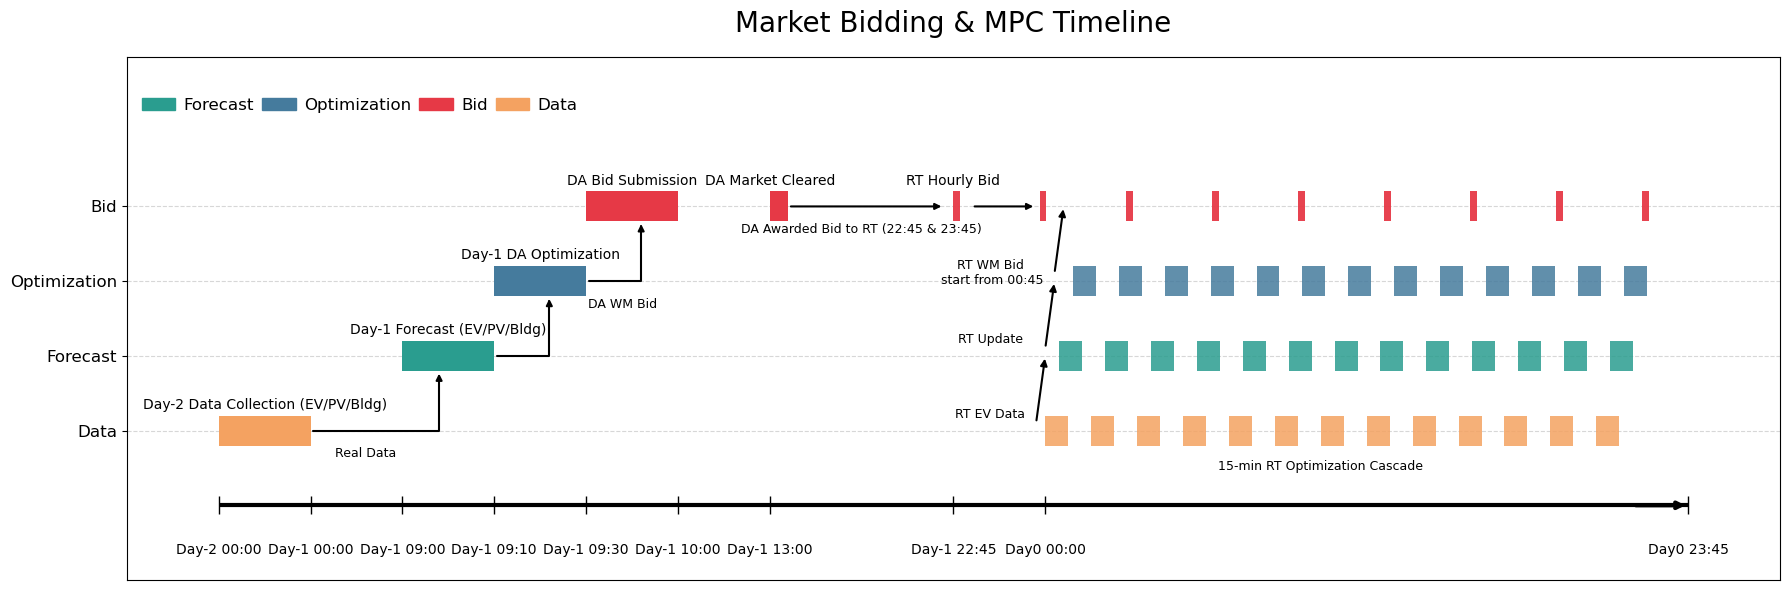

In [32]:
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024') 
print("Path is:", os.getcwd(), "\n")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.figure(figsize=(18, 6))
ax = plt.gca()


# --- 非均匀时间轴映射 ---
xmap = {
    "Day-2_00": 0,
    "Day-1_00": 1,
    "Day-1_09": 2,
    "Day-1_0910": 3,
    "Day-1_0930": 4,
    "Day-1_10": 5,
    "Day-1_13": 6,
    "Day-1_2245": 8,  # 第一个RT Bid
    "Day0_00": 9,
    "Day0_23_45": 16
}

# --- 主时间轴 ---
ax.hlines(y=0, xmin=xmap["Day-2_00"], xmax=xmap["Day0_23_45"], color="black", linewidth=3)
ax.annotate('', xy=(xmap["Day0_23_45"], 0), xytext=(xmap["Day0_23_45"] - 0.6, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=3))

# --- 标题 ---
plt.title("Market Bidding & MPC Timeline", fontsize=20, pad=18)
time_font = 10
task_font = 10
text_font = 9

# --- 时间刻度 ---
time_labels = [
    ("Day-2 00:00", "Day-2_00"),
    ("Day-1 00:00", "Day-1_00"),
    ("Day-1 09:00", "Day-1_09"),
    ("Day-1 09:10", "Day-1_0910"),
    ("Day-1 09:30", "Day-1_0930"),
    ("Day-1 10:00", "Day-1_10"),
    ("Day-1 13:00", "Day-1_13"),
    ("Day-1 22:45", "Day-1_2245"),
    ("Day0 00:00", "Day0_00"),
    ("Day0 23:45", "Day0_23_45"),
]
for label, key in time_labels:
    x = xmap[key]
    ax.vlines(x, ymin=-0.12, ymax=0.12, color="black", linewidth=1)
    ax.text(x, -0.5, label, ha="center", va="top", fontsize=time_font)

# --- y层 ---
y_layers = {"Data":1.0,"Forecast":2.0,"Optimization":3.0,"Bid":4.0}
height = 0.4

# --- Day-2 -> Day-1 Data ---
ax.broken_barh([(xmap["Day-2_00"], xmap["Day-1_00"]-xmap["Day-2_00"])],
               (y_layers["Data"]-height/2, height), facecolors="#F4A261")
ax.text((xmap["Day-2_00"] + xmap["Day-1_00"])/2, y_layers["Data"] + 0.25,
        "Day-2 Data Collection (EV/PV/Bldg)", ha="center", va="bottom", fontsize=task_font)

# --- Day-1 Forecast ---
ax.broken_barh([(xmap["Day-1_09"], xmap["Day-1_0910"]-xmap["Day-1_09"])],
               (y_layers["Forecast"]-height/2, height), facecolors="#2A9D8F")
ax.text((xmap["Day-1_09"] + xmap["Day-1_0910"])/2, y_layers["Forecast"] + 0.25,
        "Day-1 Forecast (EV/PV/Bldg)", ha="center", va="bottom", fontsize=task_font)

# --- Day-1 Optimization ---
ax.broken_barh([(xmap["Day-1_0910"], xmap["Day-1_0930"]-xmap["Day-1_0910"])],
               (y_layers["Optimization"]-height/2, height), facecolors="#457B9D")
ax.text((xmap["Day-1_0910"] + xmap["Day-1_0930"])/2, y_layers["Optimization"] + 0.25,
        "Day-1 DA Optimization", ha="center", va="bottom", fontsize=task_font)

# --- Day-1 DA Bid ---
ax.broken_barh([(xmap["Day-1_0930"], xmap["Day-1_10"]-xmap["Day-1_0930"])],
               (y_layers["Bid"]-height/2, height), facecolors="#E63946")
ax.text((xmap["Day-1_0930"] + xmap["Day-1_10"])/2, y_layers["Bid"] + 0.25,
        "DA Bid Submission", ha="center", va="bottom", fontsize=task_font)

# --- Day-1 market clear ---
ax.broken_barh([(xmap["Day-1_13"], 0.2)],
               (y_layers["Bid"]-height/2, height), facecolors="#E63946")
ax.text(xmap["Day-1_13"], y_layers["Bid"] + 0.25,
        "DA Market Cleared", ha="center", va="bottom", fontsize=task_font)




# --- Day0 Forecast+Optimization 循环 ---
day0_start, day0_end = xmap["Day0_00"], xmap["Day0_23_45"]
step = 0.5
x_positions = np.arange(day0_start, day0_end, step)
for i, x in enumerate(x_positions):
    if x + 2*step > day0_end: break
    # Data block（示意放在循环前面，长度可以为 step*0.2）
    ax.broken_barh([(x, step*0.5)], (y_layers["Data"]-height/2, height), facecolors="#F4A261", alpha=0.85)
    # Forecast block
    ax.broken_barh([(x + step*0.3, step*0.5)], (y_layers["Forecast"]-height/2, height), facecolors="#2A9D8F", alpha=0.85)
    # Optimization block
    ax.broken_barh([(x + step*0.6, step*0.5)], (y_layers["Optimization"]-height/2, height), facecolors="#457B9D", alpha=0.85)

# --- RT Bid --- 
rt_start = xmap["Day-1_2245"]
num_hourly = 9
rt_xs = np.linspace(rt_start, day0_end - 1.0*step, num_hourly)
for i, rx in enumerate(rt_xs):
    ax.broken_barh([(rx, step*0.15)], (y_layers["Bid"]-height/2, height), facecolors="#E63946", alpha=0.95)
    if i == 0:
        # 第一个RT Bid文字
        # ax.text(rx, y_layers["Bid"] - 0.25, "Day-1 22:45 & 23:45 RT Bid = DA Bid", ha="center", va="top", fontsize=text_font)
        ax.text(rx, y_layers["Bid"] + 0.25, "RT Hourly Bid", ha="center", va="bottom", fontsize=task_font)
        # Data -> Forecast arrow
        ax.annotate('',
            xy=(xmap["Day0_00"], y_layers["Forecast"]),  # 箭头终点
            xytext=(xmap["Day0_00"] - 0.1, y_layers["Data"] + 0.1),   # 箭头起点
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5))  # 直线箭头
        x_corner = xmap["Day0_00"] - 0.6    # 水平到达的位置
        y_corner = y_layers["Data"] + 0.3    # 箭头起点高度
        ax.text(x_corner, y_corner, "RT EV Data", ha='center', va='top', fontsize=text_font)
        # Forecast -> Optimization arrow
        ax.annotate('',
            xy=(xmap["Day0_00"] + 0.1, y_layers["Optimization"]),  # 箭头终点
            xytext=(xmap["Day0_00"], y_layers["Forecast"] + 0.1),   # 箭头起点
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5))  # 直线箭头
        x_corner = xmap["Day0_00"] - 0.6    # 水平到达的位置
        y_corner = y_layers["Forecast"] + 0.3    # 箭头起点高度
        ax.text(x_corner, y_corner, "RT Update", ha='center', va='top', fontsize=text_font)
        # Optimization -> RT Bid arrow
        ax.annotate('',
            xy=(xmap["Day0_00"] + 0.2, y_layers["Bid"]),  # 箭头终点
            xytext=(xmap["Day0_00"] + 0.1, y_layers["Optimization"] + 0.1),   # 箭头起点
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5))  # 直线箭头
        x_corner = xmap["Day0_00"] - 0.6    # 水平到达的位置
        y_corner = y_layers["Optimization"] + 0.3    # 箭头起点高度
        ax.text(x_corner, y_corner, "RT WM Bid\n start from 00:45", ha='center', va='top', fontsize=text_font)


ax.text(xmap["Day0_00"] + 3, y_layers["Data"] - 0.4, "15-min RT Optimization Cascade", ha="center", va="top", fontsize=text_font)


# --- 在 block 之间添加箭头 --- 
# 例如：Day-2 Data -> Day-1 Forecast
ax.annotate('', 
            xy=(xmap["Day-1_09"] + 0.4, y_layers["Forecast"] - 0.2),
            xytext=(xmap["Day-1_00"], y_layers["Data"]),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5, connectionstyle="angle,angleA=0,angleB=90,rad=0"), 
            fontsize=text_font, ha='center', va='bottom')

x_corner = xmap["Day-1_00"] + 0.6    # 水平到达的位置
y_corner = y_layers["Data"] - 0.1    # 箭头起点高度
ax.text(x_corner, y_corner - 0.12, "Real Data", ha='center', va='top', fontsize=text_font)

# Day-1 Forecast -> Day-1 Optimization
ax.annotate('', 
            xy=(xmap["Day-1_0910"] + 0.6, y_layers["Optimization"] - 0.2),
            xytext=(xmap["Day-1_0910"], y_layers["Forecast"]),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5, connectionstyle="angle,angleA=0,angleB=90,rad=0"), 
            fontsize=text_font, ha='center', va='bottom')

# Day-1 Optimization -> DA Bid
ax.annotate('', 
            xy=(xmap["Day-1_10"] - 0.4, y_layers["Bid"] - 0.2),
            xytext=(xmap["Day-1_0930"], y_layers["Optimization"]),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5, connectionstyle="angle,angleA=0,angleB=90,rad=0"), 
            fontsize=text_font, ha='center', va='bottom')

x_corner = xmap["Day-1_0930"] + 0.4    # 水平到达的位置
y_corner = y_layers["Optimization"] - 0.1    # 箭头起点高度
ax.text(x_corner, y_corner - 0.12, "DA WM Bid", ha='center', va='top', fontsize=text_font)

# Day-1 Market Clear -> RT Bid
ax.annotate('', 
            xy=(xmap["Day-1_2245"] - 0.1, y_layers["Bid"]),
            xytext=(xmap["Day-1_13"] + 0.2, y_layers["Bid"]),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5), 
            fontsize=text_font, ha='center', va='bottom')
x_corner = xmap["Day-1_13"] + 1    # 水平到达的位置
y_corner = y_layers["Bid"] - 0.1    # 箭头起点高度
ax.text(x_corner, y_corner - 0.12, "DA Awarded Bid to RT (22:45 & 23:45)", ha='center', va='top', fontsize=text_font)

ax.annotate('', 
            xy=(xmap["Day0_00"] - 0.1, y_layers["Bid"]),
            xytext=(xmap["Day-1_2245"] + 0.2, y_layers["Bid"]),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5), 
            fontsize=text_font, ha='center', va='bottom')


# --- Y层侧边彩色标签 ---
legend_patches = [
    mpatches.Patch(color="#2A9D8F", label="Forecast"),
    mpatches.Patch(color="#457B9D", label="Optimization"),
    mpatches.Patch(color="#E63946", label="Bid"),
    mpatches.Patch(color="#F4A261", label="Data")
]
ax.legend(handles=legend_patches, 
          fontsize=12, 
          frameon=False, 
          ncol=4,
          bbox_to_anchor=(0, 0.95),
          loc='upper left', 
          columnspacing=0.5,  # 列间距，可调节紧凑度
          handletextpad=0.5)  # 图例标记和文字间距

# --- 美化、网格与完整边框 ---
ax.set_yticks([y_layers["Data"], y_layers["Forecast"], y_layers["Optimization"], y_layers["Bid"]])
ax.set_yticklabels(["Data", "Forecast", "Optimization", "Bid"], fontsize=12)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.spines[['left','right','top','bottom']].set_visible(True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.set_xlim(-1, 17)   # x 轴左右留白
ax.set_ylim(-1, 6)  # y 轴上下留白

plt.tight_layout()
plt.savefig('Results/Plots/Timeline_Market_Bidding_MPC.png', dpi=300, bbox_inches='tight')
plt.show()